# Libraries

In [29]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
import matplotlib.pyplot as plt

from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,
export_text)
from sklearn.metrics import (accuracy_score,
log_loss)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from sklearn.model_selection import GridSearchCV

# Tree Based Models

## Load Data

In [5]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("county_scaled.txt")

Saving county_scaled.txt to county_scaled (2).txt


## Data Prep

### Create X and Y

In [43]:
target = "total_EV_count"

X = df.drop(columns=["county", target])
y = df[target]

### Train/test split

In [44]:
X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=0.25, random_state=0)

# Fit Baseline Regrerssion Tree

[Text(0.625, 0.875, 'level2_chargers <= 3.271\nsquared_error = 1.316\nsamples = 29\nvalue = 0.079'),
 Text(0.5, 0.625, 'dc_fast_chargers <= 0.484\nsquared_error = 0.107\nsamples = 28\nvalue = -0.129'),
 Text(0.5625, 0.75, 'True  '),
 Text(0.25, 0.375, 'total_chargers <= -0.056\nsquared_error = 0.011\nsamples = 25\nvalue = -0.232'),
 Text(0.125, 0.125, 'squared_error = 0.002\nsamples = 22\nvalue = -0.268'),
 Text(0.375, 0.125, 'squared_error = 0.002\nsamples = 3\nvalue = 0.033'),
 Text(0.75, 0.375, 'total_EV_count_log <= 1.638\nsquared_error = 0.089\nsamples = 3\nvalue = 0.727'),
 Text(0.625, 0.125, 'squared_error = 0.018\nsamples = 2\nvalue = 0.531'),
 Text(0.875, 0.125, 'squared_error = 0.0\nsamples = 1\nvalue = 1.118'),
 Text(0.75, 0.625, 'squared_error = 0.0\nsamples = 1\nvalue = 5.905'),
 Text(0.6875, 0.75, '  False')]

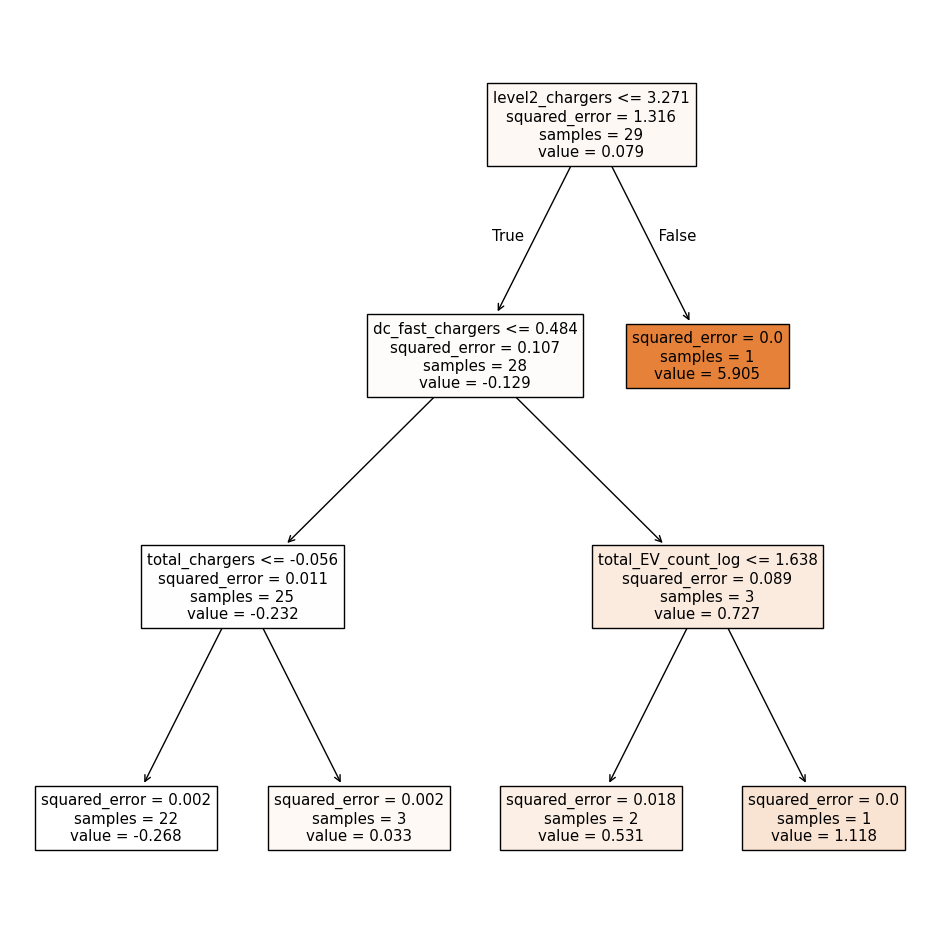

In [45]:
reg = DTR(max_depth=3)
reg.fit(X_train, y_train)
ax = subplots(figsize=(12,12))[1]
plot_tree(reg, ax=ax, feature_names=X.columns, filled=True)

In [46]:
leaf_ids = reg.apply(X)

leaf_table = pd.DataFrame({
  "county": df["county"],
  "leaf_id": leaf_ids,
  "prediction": reg.predict(X)
})

leaf_summary = leaf_table.groupby("leaf_id").agg({
  "county": lambda x: ", ".join(x),
  "prediction": "first"
})
leaf_summary

,county,prediction
leaf_id,,
3,"ADAMS, ASOTIN, BENTON, CHELAN, CLALLAM, COLUMB...",-0.267850
4,"KITSAP, SKAGIT, SPOKANE, THURSTON, WHATCOM",0.033411
6,"CLARK, PIERCE",0.530726
7,SNOHOMISH,1.118069
8,KING,5.905192


## Cross Validation

In [52]:
# Parameters to tune
params = {
    "max_leaf_nodes": range(2, 15),
    "max_depth": range(1, 10)
}
cv_ev = GridSearchCV(DTR(random_state=0), params, cv=5)
cv_ev.fit(X_train, y_train)
cv_results = cv_ev.cv_results_

Best max leaf nodes: 13
Best max depth: 6


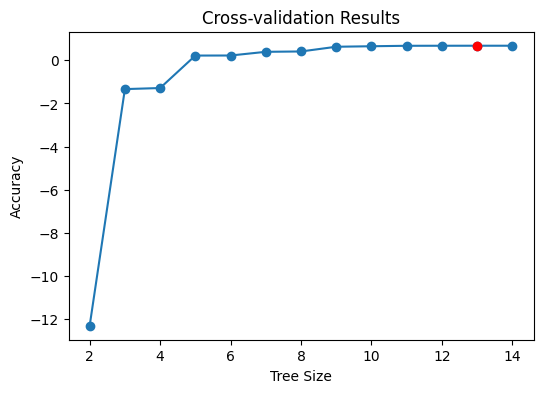

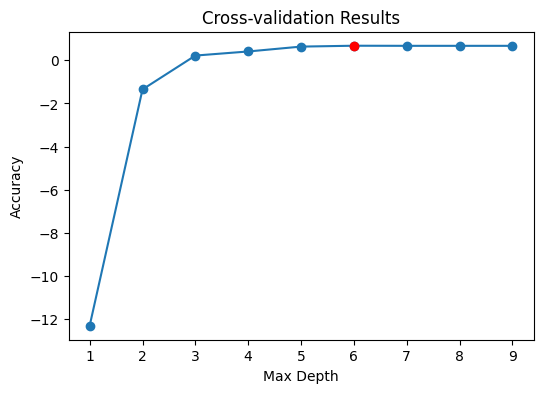

In [53]:
# Best score for max leaf nodes
best_size = cv_ev.best_params_["max_leaf_nodes"]
best_depth = cv_ev.best_params_["max_depth"]

print(f"Best max leaf nodes: {best_size}")
print(f"Best max depth: {best_depth}")

best_score = cv_ev.best_score_
results_df = pd.DataFrame(cv_results)

# Max leaf nodes
leaf_results = results_df[
    results_df["param_max_depth"] == best_depth
].sort_values("param_max_leaf_nodes")

plt.figure(figsize=(6, 4))
plt.plot(leaf_results["param_max_leaf_nodes"], leaf_results["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results')
plt.show()

# Max depth
depth_results = results_df[
    results_df["param_max_leaf_nodes"] == best_size
].sort_values("param_max_depth")

plt.figure(figsize=(6, 4))
plt.plot(depth_results["param_max_depth"], depth_results["mean_test_score"], 'o-')
plt.plot(best_depth, best_score, 'ro-')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results')
plt.show()

# Regression Tree based on CV

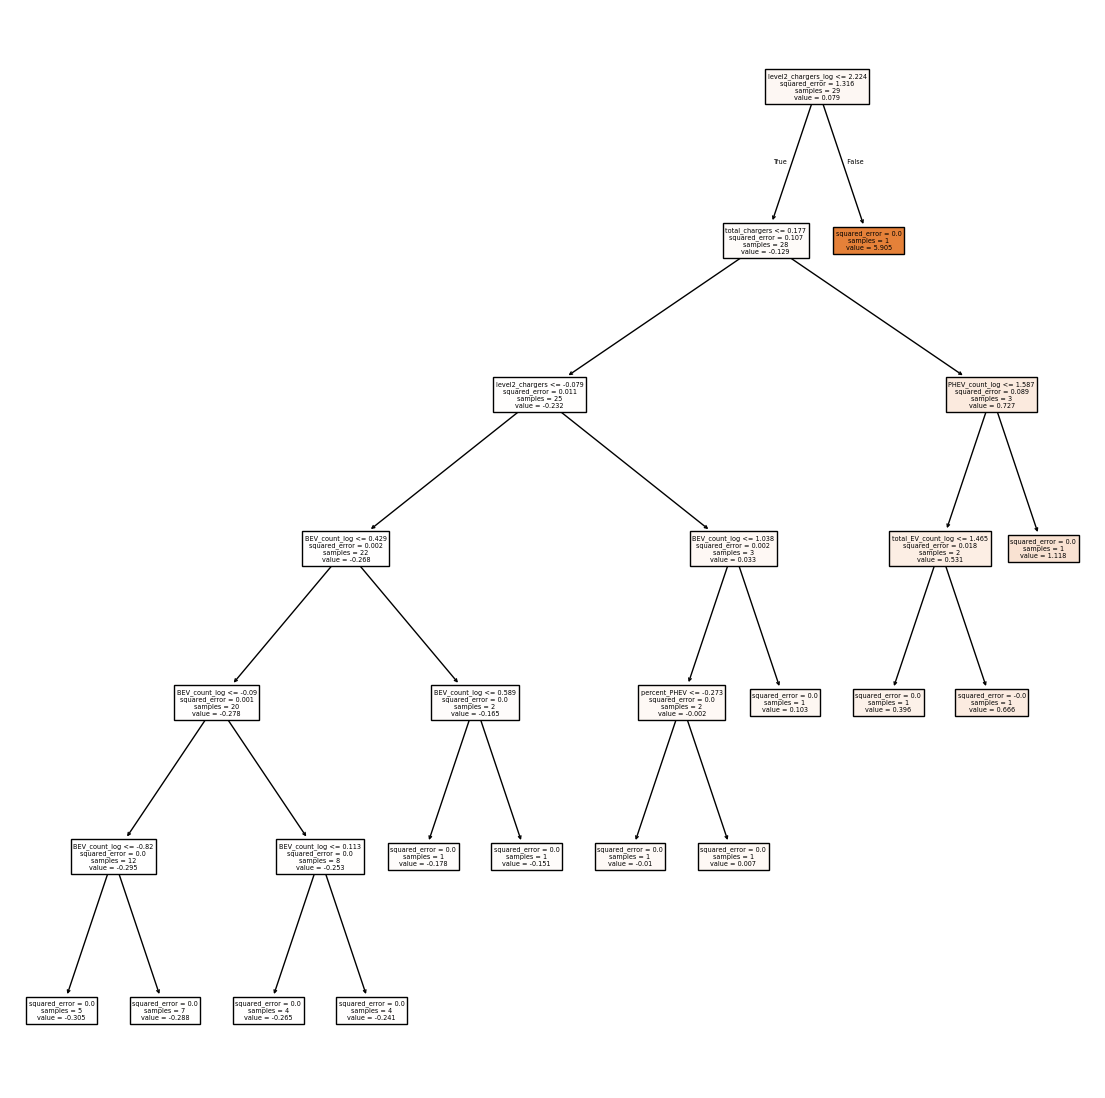

In [57]:
reg_cv = DTR(max_depth=6, max_leaf_nodes=13, random_state=0)
reg_cv.fit(X_train, y_train)
ax = subplots(figsize=(14,14))[1]
plot_tree(reg_cv, ax=ax, feature_names=X.columns, filled=True);

In [60]:
leaf_ids_cv = reg_cv.apply(X)

leaf_table = pd.DataFrame({
  "county": df["county"],
  "leaf_id": leaf_ids_cv,
  "prediction": reg_cv.predict(X)
})

leaf_summary = leaf_summary.sort_values(
    "prediction",
    ascending=False
)
leaf_summary

,county,prediction
leaf_id,,
2,KING,5.905192
8,SNOHOMISH,1.118069
10,PIERCE,0.665848
9,CLARK,0.395603
16,"KITSAP, THURSTON",0.103350
24,SPOKANE,0.007261
23,WHATCOM,-0.010379
22,BENTON,-0.151110
21,"ISLAND, SKAGIT",-0.178299


This decision tree regression model was used to analyze EV adoption across Washington State counties. CV identified an optimal tree with a maximum depth of 6 and 13 leaf nodes. The results showed that charger infastructure variables were among the most important factors influencing EV adoption. King and Snohomish counties had the highest predicted adoption levels, while many rural counties were grouped into lower adoption categories.

# Bagging

In [61]:
bag_EV = RF(max_features=X_train.shape[1])
bag_EV.fit(X_train, y_train)

RandomForestRegressor(max_features=23)

## Initial Bagging Results

np.float64(0.0006624438559952793)

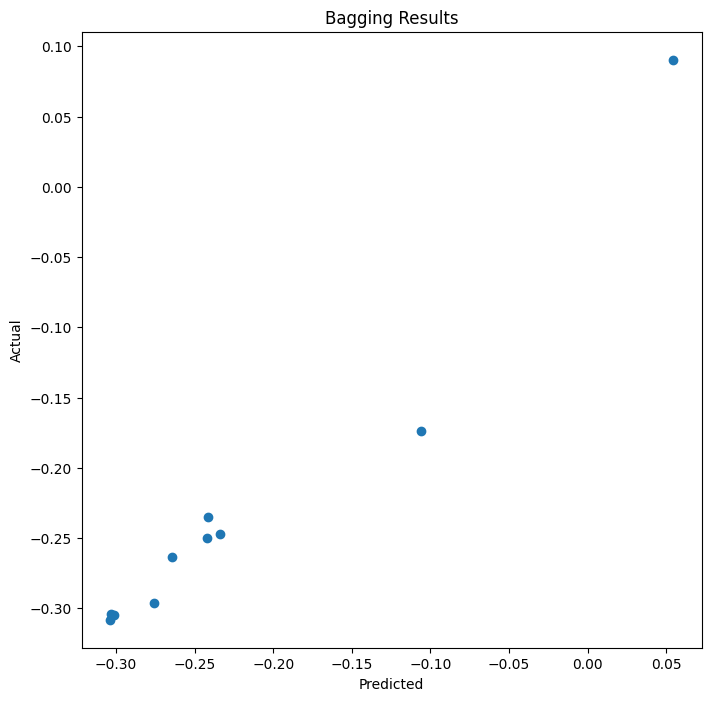

In [63]:
ax = subplots(figsize=(8,8))[1]

y_hat_bag = bag_EV.predict(X_test)

ax.scatter(y_hat_bag, y_test)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Bagging Results")

np.mean((y_test - y_hat_bag)**2)

## Increasing the Number of Trees

In [66]:
bag_EV = RF(
    max_features=X_train.shape[1],
    n_estimators=500,
    random_state=0).fit(X_train, y_train)

y_hat_bag = bag_EV.predict(X_test)

np.mean((y_test - y_hat_bag)**2)

np.float64(0.0005574080535808776)

# Random Forest

In [67]:
RF_EV = RF(
    max_features=6,
    random_state=0).fit(X_train, y_train)

y_hat_RF = RF_EV.predict(X_test)

np.mean((y_test - y_hat_RF)**2)

np.float64(0.00030242921436631815)

# Feature Importance

In [70]:
feature_imp = pd.DataFrame(
    {'importance': RF_EV.feature_importances_},
    index=X.columns
)

feature_imp = feature_imp.sort_values(
    by='importance',
    ascending=False
)

feature_imp

,importance
total_EV_count_log,0.095609
BEV_count,0.082102
PHEV_count,0.081974
total_chargers,0.080505
median_income_2025,0.076593
dc_fast_chargers,0.073338
PHEV_count_log,0.067677
level2_chargers,0.067311
BEV_count_log,0.065539
dc_fast_chargers_log,0.064002


# Boosting

In [71]:
boost_EV = GBR(
    n_estimators=5000,
    learning_rate=0.001,
    max_depth=3,
    random_state=0)

boost_EV.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.001, n_estimators=5000,
                          random_state=0)

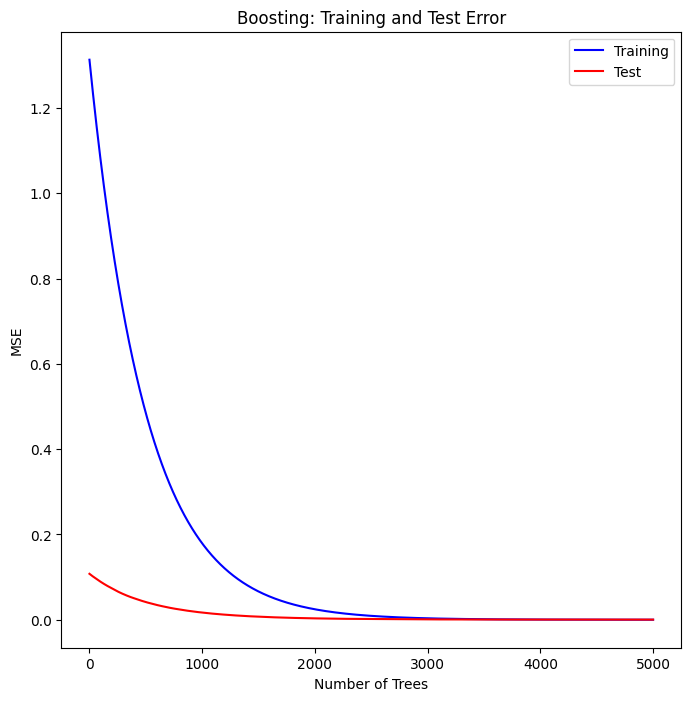

In [72]:
# Training and test error along boosting path
test_error = np.zeros_like(boost_EV.train_score_)

for idx, y_ in enumerate(boost_EV.staged_predict(X_test)):
    test_error[idx] = np.mean((y_test - y_)**2)

plot_idx = np.arange(boost_EV.train_score_.shape[0])
ax = subplots(figsize=(8,8))[1]
ax.plot(
    plot_idx,
    boost_EV.train_score_,
    'b',
    label='Training'
)

ax.plot(
    plot_idx,
    test_error,
    'r',
    label='Test'
)

ax.set_xlabel("Number of Trees")
ax.set_ylabel("MSE")
ax.set_title("Boosting: Training and Test Error")
ax.legend();

In [73]:
# Boosting test MSE
y_hat_boost = boost_EV.predict(X_test)

np.mean((y_test - y_hat_boost)**2)

np.float64(0.00030548105264863607)

In [78]:
# Increase learning rate
boost_EV = GBR(
    n_estimators=5000,
    learning_rate=0.2,
    max_depth=3,
    random_state=0
)

boost_EV.fit(X_train, y_train)

y_hat_boost = boost_EV.predict(X_test)

np.mean((y_test - y_hat_boost)**2)

np.float64(0.0010772500415790133)

## Feature Importance

In [76]:
boost_imp = pd.DataFrame(
    {'importance': boost_EV.feature_importances_},
    index=X.columns
)

boost_imp.sort_values(
    by='importance',
    ascending=False
)

,importance
level1_chargers,3.873529e-01
total_chargers,2.169543e-01
PHEV_count,1.362524e-01
dc_fast_chargers,8.765989e-02
BEV_count,5.935604e-02
dc_fast_chargers_log,2.320636e-02
total_EV_count_log,2.297362e-02
level1_chargers_log,1.934369e-02
level2_chargers_log,1.839388e-02
PHEV_count_log,1.351557e-02


# Results

## Random Forest Regression

Bagging was first applied by fitting a Random Forest model using all predictor variables at each split. The model achieved a low test MSE, indicating strong predictive performance. Increasing the number of trees from the default value to 500 produced only a small improvement, suggesting the model had already stabilized.

A Random Forest model was then fit using a subset of features at each split (max_features = 6). This model achieved a lower test MSE than bagging, indicating that introducing feature randomness improved prediction accuracy. Feature importance analysis showed that existing EV adoption measures (total_EV_count_log, BEV_count, and PHEV_count), charger infrastructure variables (total_chargers, dc_fast_chargers, and level2_chargers), and median county income were among the most influential predictors of EV adoption.

## Boosting

Gradient Boosting Regression was implemented using 5,000 trees, a maximum tree depth of 3, and a learning rate of 0.001. Training and test MSE were tracked as trees were added to the model. Both errors steadily decreased and approached zero, indicating improved model performance without substantial overfitting.

The boosted model achieved a test MSE comparable to the Random Forest model. Increasing the learning rate to 0.2 resulted in a higher test MSE, suggesting that the smaller learning rate provided better predictive performance. Feature importance analysis identified charger infrastructure variables, particularly level1_chargers, total_chargers, and dc_fast_chargers, as the most important predictors. The boosting results further supported the conclusion that charging infrastructure is a major factor associated with EV adoption across Washington State counties.

## County Level Interpretations

The machine learning models consistently identified charging infrastructure as one of the strongest predictors of EV adoption. Counties with extensive charger networks, such as King and Snohomish, exhibited the highest predicted adoption levels, while many rural counties were associated with lower adoption rates. Across all models, charger availability was a stronger predictor of EV adoption than most demographic variables, suggesting that infrastructure plays a key role in supporting EV ownership. Existing EV ownership measures were also highly important, indicating that counties with established EV markets tend to continue experiencing higher adoption levels. The results further suggest that EV adoption is concentrated in larger urban counties and is not occurring uniformly across Washington State. These findings indicate that expanding charging infrastructure, particularly in underserved counties, may be an effective strategy for supporting future EV adoption, while counties with existing infrastructure but lower adoption may be well positioned for future growth.